# Workbench do Solver

Este caderno executa o modelo em um ambiente mais controlado, sem depender da API HTTP nem da UI Streamlit. O foco aqui e validar o comportamento do solver e visualizar, com `networkx`, a rede-base do cenario e a rede escolhida.

Fluxo do notebook:

1. compilar os datasets sintéticos;
2. comparar rapidamente o resultado dos dois cenarios;
3. escolher um cenario para inspecao grafica detalhada;
4. desenhar a rede-base;
5. executar o solver real;
6. desenhar a rede escolhida pelo solver e listar as rotas.

In [1]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

PROJECT_ROOT = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Nao foi possivel localizar a raiz do repositorio a partir do diretorio atual.")

NOTEBOOK_DIR = PROJECT_ROOT / "notebook"
SRC_DIR = PROJECT_ROOT / "src"
for candidate in (NOTEBOOK_DIR, SRC_DIR):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

import solver_workbench_support as workbench
workbench = importlib.reload(workbench)

compare_default_scenarios = workbench.compare_default_scenarios
compile_default_scenarios = workbench.compile_default_scenarios
load_scenario_artifacts = workbench.load_scenario_artifacts
plot_base_graph = workbench.plot_base_graph
plot_solution_graph = workbench.plot_solution_graph
route_sequences = workbench.route_sequences
run_and_summarize = workbench.run_and_summarize
run_scenario = workbench.run_scenario
serialize_orchestration = workbench.serialize_orchestration
summarize_dataset = workbench.summarize_dataset
summarize_orchestration = workbench.summarize_orchestration

In [2]:
SCENARIO = "fake_solution"
MAX_ITERATIONS = 50
SEED = 1
MATERIALIZE_SNAPSHOT = True
WITH_BASEMAP = True
INCLUDE_RETURN_TO_BASE = True

# Troque SCENARIO para "fake_smoke" quando quiser inspecionar o caso mais agressivo.
# Se o basemap nao estiver disponivel, o notebook faz fallback para networkx puro.

## Compilacao dos datasets sintéticos

A celula abaixo recompõe a matriz sintética e materializa o snapshot local para os dois cenarios. Isso garante que `data/fake_solution` e `data/fake_smoke` estejam prontos para execucao no notebook.

In [3]:
compile_default_scenarios()

[{'cenario': 'fake_solution',
  'dataset_dir': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/fake_solution',
  'data_operacao': '2026-03-21',
  'locations': 15,
  'arcs': 225,
  'source_path': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/fake_solution/logistics_sources/2026-03-21.json',
  'snapshot_id': 'snap-fake_solution-2026-03-21',
  'snapshot_path': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/fake_solution/logistics_snapshots/2026-03-21.json',
  'version_path': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/fake_solution/logistics_snapshots/versions/2026-03-21/snap-fake_solution-2026-03-21.json',
  'manifest_path': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/fake_solution/logistics_snapshots/versions/2026-03-21/manifest.json'},
 {'cenario': 'fake_smoke',
  'dataset_dir': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/

In [4]:
compare_default_scenarios(
    max_iterations=MAX_ITERATIONS,
    seed=SEED,
    materialize_snapshot=MATERIALIZE_SNAPSHOT,
)

[{'id_execucao': 'exec-solution-2026-03-21',
  'status_final': 'concluida',
  'hash_cenario': '060bced4e91f07dec08920336f5ac3469fe2b408b712929562042854533a58ae',
  'reused_cached_result': False,
  'recovered_previous_context': False,
  'attempt_number': 1,
  'total_rotas': 8,
  'rotas_suprimento': 4,
  'rotas_recolhimento': 4,
  'ordens_planejadas': 10,
  'ordens_nao_atendidas': 0,
  'taxa_atendimento': '1.0000',
  'utilizacao_frota': '0.8000',
  'custo_total_estimado': '8417.05',
  'resultado_json': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/fake_solution/outputs/executions/060bced4e91f07dec08920336f5ac3469fe2b408b712929562042854533a58ae/resultado-planejamento.json',
  'cenario': 'fake_solution'},
 {'id_execucao': 'exec-smoke-2026-03-21',
  'status_final': 'concluida_com_ressalvas',
  'hash_cenario': '35a0adaacd272be22ec3e639fa01faea517bb86060e28812da432748fcfd8e2e',
  'reused_cached_result': False,
  'recovered_previous_context': False,
  'attempt_numbe

## Inspecao detalhada do cenario selecionado

A partir daqui, o fluxo grafico vale para o cenario definido em `SCENARIO`.

In [5]:
artifacts = load_scenario_artifacts(SCENARIO)
summarize_dataset(artifacts)

{'cenario': 'fake_solution',
 'dataset_dir': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/fake_solution',
 'data_operacao': '2026-03-21',
 'bases': 5,
 'pontos_catalogados': 10,
 'viaturas': 5,
 'ordens_do_dia': 10,
 'arcos_matriz': 225,
 'estrategia_matriz': 'synthetic_geodesic_v1',
 'fonte_matriz': 'fake_solution_source'}

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Rede-base do cenario fake_solution com basemap'}, xlabel='Longitude', ylabel='Latitude'>)

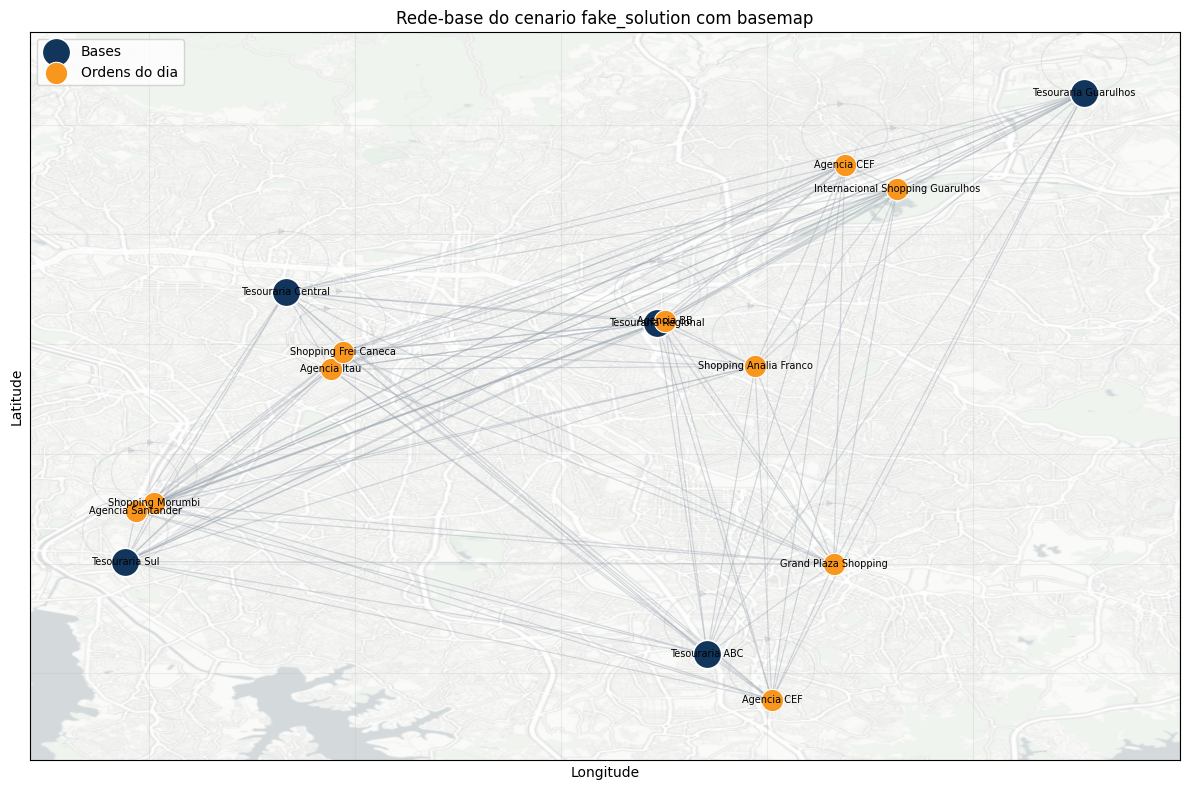

In [6]:
plot_base_graph(artifacts, with_basemap=WITH_BASEMAP)

## Execucao do solver

A celula abaixo chama o `DailyPlanningOrchestrator` diretamente. Isso elimina o acoplamento com API/UI e e o jeito certo de avaliar o modelo em isolamento.

In [7]:
orchestration = run_scenario(
    SCENARIO,
    max_iterations=MAX_ITERATIONS,
    seed=SEED,
    materialize_snapshot=MATERIALIZE_SNAPSHOT,
)
summarize_orchestration(orchestration)

{'id_execucao': 'exec-solution-2026-03-21',
 'status_final': 'concluida',
 'hash_cenario': '060bced4e91f07dec08920336f5ac3469fe2b408b712929562042854533a58ae',
 'reused_cached_result': True,
 'recovered_previous_context': True,
 'attempt_number': 1,
 'total_rotas': 8,
 'rotas_suprimento': 4,
 'rotas_recolhimento': 4,
 'ordens_planejadas': 10,
 'ordens_nao_atendidas': 0,
 'taxa_atendimento': '1.0000',
 'utilizacao_frota': '0.8000',
 'custo_total_estimado': '8417.05',
 'resultado_json': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/fake_solution/outputs/executions/060bced4e91f07dec08920336f5ac3469fe2b408b712929562042854533a58ae/resultado-planejamento.json'}

In [8]:
route_sequences(orchestration, include_return_to_base=INCLUDE_RETURN_TO_BASE)

[{'id_rota': 'rota-exec-solution-2026-03-21-suprimento-001',
  'id_viatura': 'V-CENTRO-01',
  'classe_operacional': 'suprimento',
  'quantidade_paradas': 1,
  'inicio_previsto': '2026-03-21T08:50:02+00:00',
  'fim_previsto': '2026-03-21T09:29:58+00:00',
  'sequencia': 'BASE-SP-CENTRO -> P-CENTRO-01 -> BASE-SP-CENTRO',
  'ordens': ['ORD-SOL-001-CENTRO-SUP']},
 {'id_rota': 'rota-exec-solution-2026-03-21-suprimento-002',
  'id_viatura': 'V-LESTE-01',
  'classe_operacional': 'suprimento',
  'quantidade_paradas': 2,
  'inicio_previsto': '2026-03-21T08:07:18+00:00',
  'fim_previsto': '2026-03-21T09:35:19+00:00',
  'sequencia': 'BASE-SP-LESTE -> P-NORTE-02 -> P-LESTE-01 -> BASE-SP-LESTE',
  'ordens': ['ORD-SOL-009-NORTE-SUP', 'ORD-SOL-003-LESTE-SUP']},
 {'id_rota': 'rota-exec-solution-2026-03-21-suprimento-003',
  'id_viatura': 'V-SUL-01',
  'classe_operacional': 'suprimento',
  'quantidade_paradas': 1,
  'inicio_previsto': '2026-03-21T09:52:32+00:00',
  'fim_previsto': '2026-03-21T10:37:28+0

(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'left': 'Rede escolhida pelo solver com basemap\n10 ordem(ns) planejada(s) | 0 nao atendida(s)'}, xlabel='Longitude', ylabel='Latitude'>)

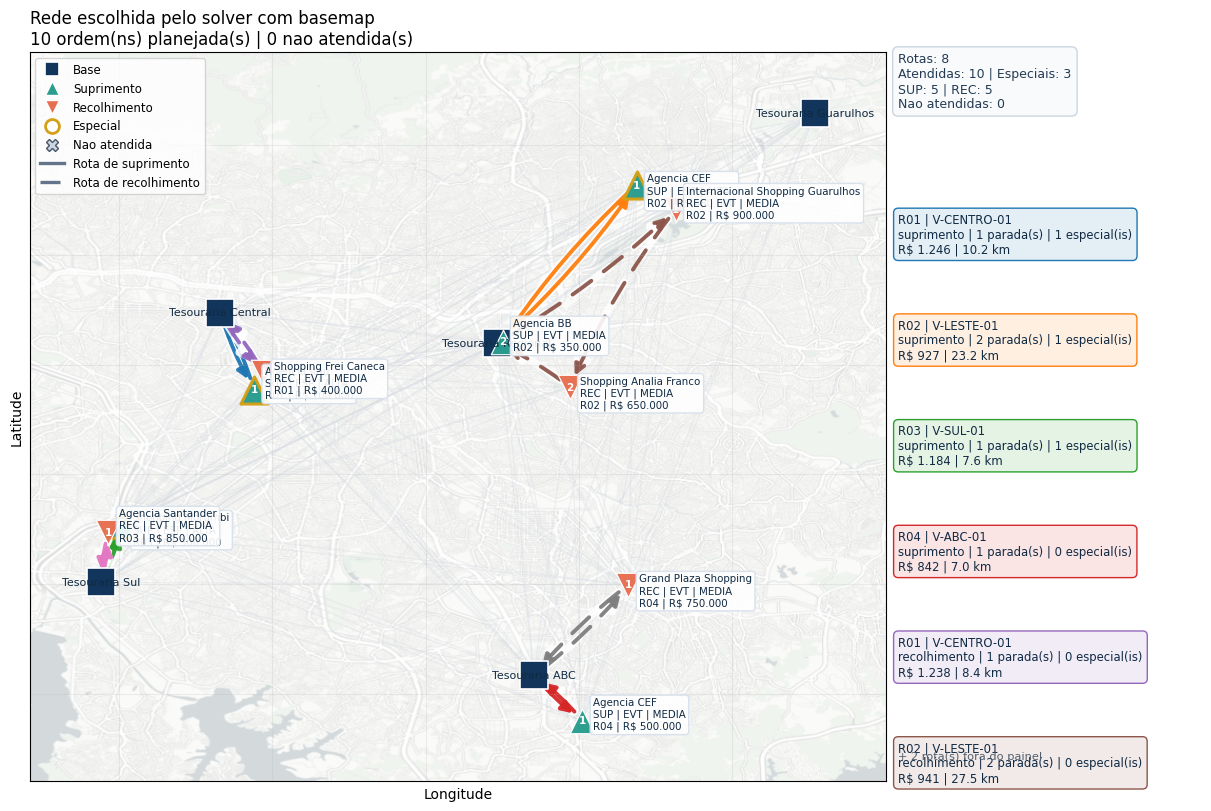

In [9]:
plot_solution_graph(
    orchestration,
    artifacts,
    include_return_to_base=INCLUDE_RETURN_TO_BASE,
    with_basemap=WITH_BASEMAP,
)

In [10]:
serialized = serialize_orchestration(orchestration)
{
    "cenario": SCENARIO,
    "status_final": serialized["result"]["status_final"],
    "resultado_json": serialized["result_path"],
    "total_rotas": serialized["result"]["resumo_operacional"]["total_rotas"],
    "total_ordens_planejadas": serialized["result"]["resumo_operacional"]["total_ordens_planejadas"],
    "total_ordens_nao_atendidas": serialized["result"]["resumo_operacional"]["total_ordens_nao_atendidas"],
}

{'cenario': 'fake_solution',
 'status_final': 'concluida',
 'resultado_json': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/fake_solution/outputs/executions/060bced4e91f07dec08920336f5ac3469fe2b408b712929562042854533a58ae/resultado-planejamento.json',
 'total_rotas': 8,
 'total_ordens_planejadas': 10,
 'total_ordens_nao_atendidas': 0}

## Atalho rapido para o `fake_smoke`

Se quiser apenas verificar o comportamento do cenário mais agressivo sem trocar a variavel `SCENARIO`, rode a celula abaixo.

In [11]:
run_and_summarize(
    "fake_smoke",
    max_iterations=MAX_ITERATIONS,
    seed=SEED,
    materialize_snapshot=MATERIALIZE_SNAPSHOT,
)

{'id_execucao': 'exec-smoke-2026-03-21',
 'status_final': 'concluida_com_ressalvas',
 'hash_cenario': '35a0adaacd272be22ec3e639fa01faea517bb86060e28812da432748fcfd8e2e',
 'reused_cached_result': True,
 'recovered_previous_context': True,
 'attempt_number': 1,
 'total_rotas': 12,
 'rotas_suprimento': 7,
 'rotas_recolhimento': 5,
 'ordens_planejadas': 19,
 'ordens_nao_atendidas': 1,
 'taxa_atendimento': '0.9500',
 'utilizacao_frota': '0.8000',
 'custo_total_estimado': '11147.06',
 'resultado_json': '/home/thiagobibianodasilva/Documentos/aredes-roteirizacao-numerario/data/fake_smoke/outputs/executions/35a0adaacd272be22ec3e639fa01faea517bb86060e28812da432748fcfd8e2e/resultado-planejamento.json',
 'cenario': 'fake_smoke'}

(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'left': 'Rede escolhida pelo solver\n10 ordem(ns) planejada(s) | 0 nao atendida(s)'}, xlabel='Longitude', ylabel='Latitude'>)

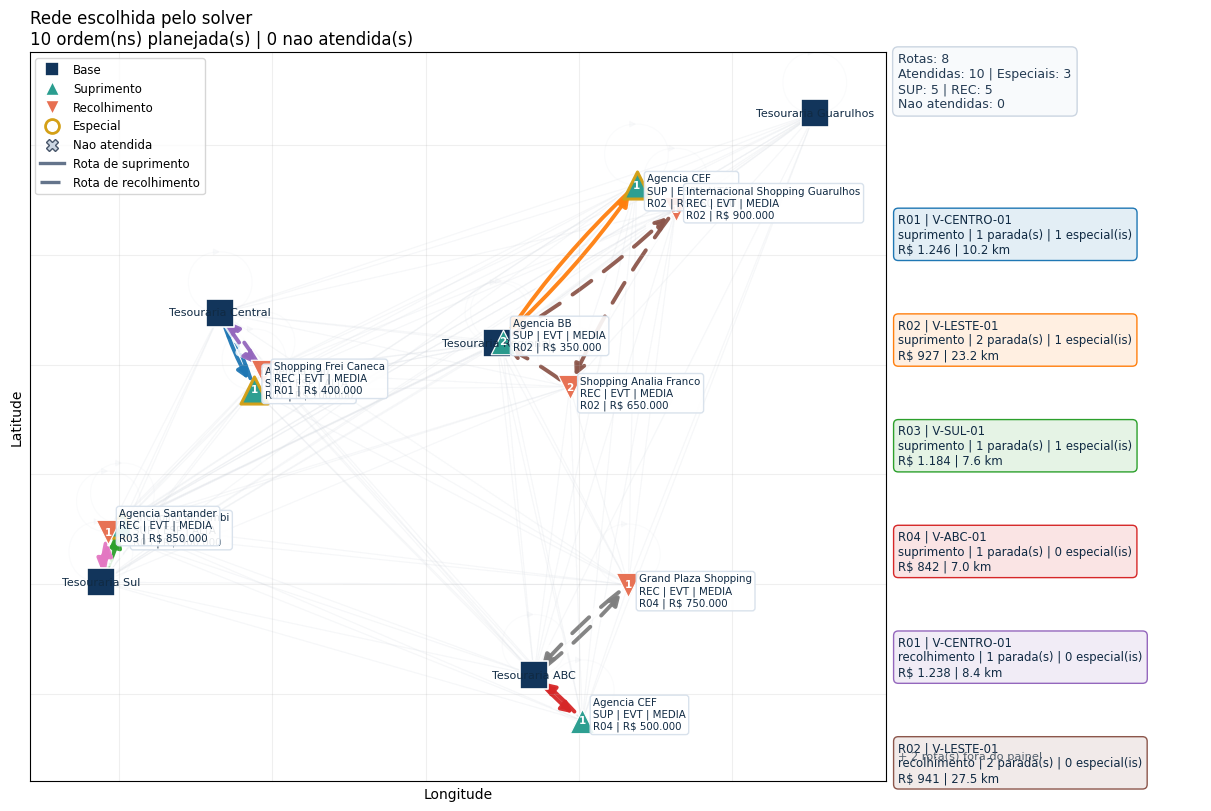

In [12]:
plot_solution_graph(
    orchestration,
    artifacts,
    include_return_to_base=INCLUDE_RETURN_TO_BASE,
)